# Kundensegmentierung
## 1. Ziel
Nutzer in sinnvolle Segmente gruppieren
Segmente interpretieren
Für jedes Segment den passenden Perk bestimmen
Ergebnisse dokumentieren und visualisieren

## 2. Arbeitspakete
Daten laden & sanity checks
Feature‑Selektion für Clustering
Regelbasierte Vor‑Segmentierung
ML‑Clustering (K‑Means / HDBSCAN)
Cluster interpretieren
Perk‑Zuordnung
Dokumentation & Visualisierung

### Warum wir K‑Means / HDBSCAN und nicht RandomForest für die Segmentierung verwenden
Segmentierung = Unsupervised Learning
Wir haben keine Zielvariable.
Wir wollen Gruppen finden, nicht etwas vorhersagen.

Daher verwenden wir:

K‑Means → kompakte, runde Cluster

HDBSCAN → flexible Cluster, erkennt Noise

Diese Methoden sind ideal für Week 3.

Warum nicht RandomForest / XGBoost?
RandomForest und XGBoost sind Supervised Learning Modelle.
Sie benötigen eine Zielvariable (Label).

Die haben wir erst, nachdem wir Cluster erzeugt haben.

Wie beide Methoden zusammengehören
Clustering (Unsupervised)
→ K‑Means / HDBSCAN
→ erzeugt Cluster‑Labels

Feature Importance (Supervised)
→ RandomForest / XGBoost
→ erklärt, welche Features die Cluster bestimmen

Feature Reduction
→ Entfernen schwacher oder redundanter Features

Finales Clustering
→ stabilere, interpretierbare Segmente

Fazit
K‑Means / HDBSCAN = Segmentierung

RandomForest / XGBoost = Erklärung der Segmente

Beide Methoden gehören zusammen, aber in der richtigen Reihenfolge

# Step 1 - Daten laden + Sanity Checks

In [44]:
import pandas as pd

# Pfad zur User-Feature-Tabelle
path = r"C:\_AA-LapTop-MSIT\_MyMSIT_MasteryProject_Term7\01_data\processed\STEP1_user_features.csv"

# Laden der Daten
user_features = pd.read_csv(path)

# Erste Übersicht
print("Shape:", user_features.shape)
print("\nSpalten:")
print(user_features.columns.tolist())

# Datentypen prüfen
print("\nDtypes:")
print(user_features.dtypes)

# Fehlende Werte prüfen
print("\nMissing Values:")
print(user_features.isna().sum().sort_values(ascending=False).head(20))

# Grundlegende Statistik
print("\nDescribe:")
print(user_features.describe(include='all').T.head(20))


Shape: (5782, 40)

Spalten:
['user_id', 'sessions_ttl', 'clicks_avg', 'conversionRate_avg', 'cancellations_ttl', 'flights_booked_ttl', 'hotels_booked_ttl', 'flightBookingRate', 'hotelBookingRate', 'nightsPerTrip_avg', 'nightsPerTrip_max', 'lead_time_flight_days_avg', 'lead_time_flight_days_median', 'lead_time_flight_days_std', 'business_weekday_rate', 'flight_discount_proportion_avg', 'flight_discount_amount_avg', 'hotel_discount_proportion_avg', 'hotel_discount_amount_avg', 'ads_per_km', 'session_time_sec_avg', 'session_time_sec_max', 'climate_segment_mode', 'winter_escape_rate', 'distance_category_mode', 'recency_days_flight', 'flight_price_avg', 'unique_destinations_count', 'airline_diversity_count', 'winter_travel_rate', 'summer_travel_rate', 'hotel_price_avg', 'tropics_rate', 'trips_per_active_month', 'flight_revenue_total', 'hotel_revenue_total', 'revenue_total_user', 'revenue_per_trip_avg', 'total_discount_savings', 'clicks_ttl']

Dtypes:
user_id                             int6

## Ergebnis:
### 1. Die Missing Values sind sinnvoll und kein Problem
Gruppe A: 927 Nutzer ohne Buchungen
→ alle Buchungs‑Features fehlen
→ das ist korrekt, nicht fehlerhaft
→ diese Nutzer sind Kandidaten für das Segment „Dreamers“

#### Gruppe B: Discount‑Amount‑Features
→ viele Nutzer haben nie Discounts gesehen
→ daher NaN → korrekt
→ ersetzen später durch 0

### 2. Kategorische Features sind sauber
climate_segment_mode
distance_category_mode
Beide sind Strings → encoden später.

### 3. Keine offensichtlichen Ausreißer, aber einige Features haben extreme Max‑Werte
Beispiele:
lead_time_flight_days_avg max = 365
lead_time_flight_days_std max = 253
session_time_sec_avg max = 2137
Das ist normal → skalieren später.

### 4. Die Feature‑Matrix ist vollständig und ML‑ready
nur vorher:
Missing Values behandeln
Kategorische Features encoden
Features skalieren
Optional: Feature‑Selektion durchführen

## 📊 STEP 1.5 — Verteilungsanalyse

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# from diptest import diptest   # functioniert nicht unter pycharm

In [46]:
df = user_features.copy()

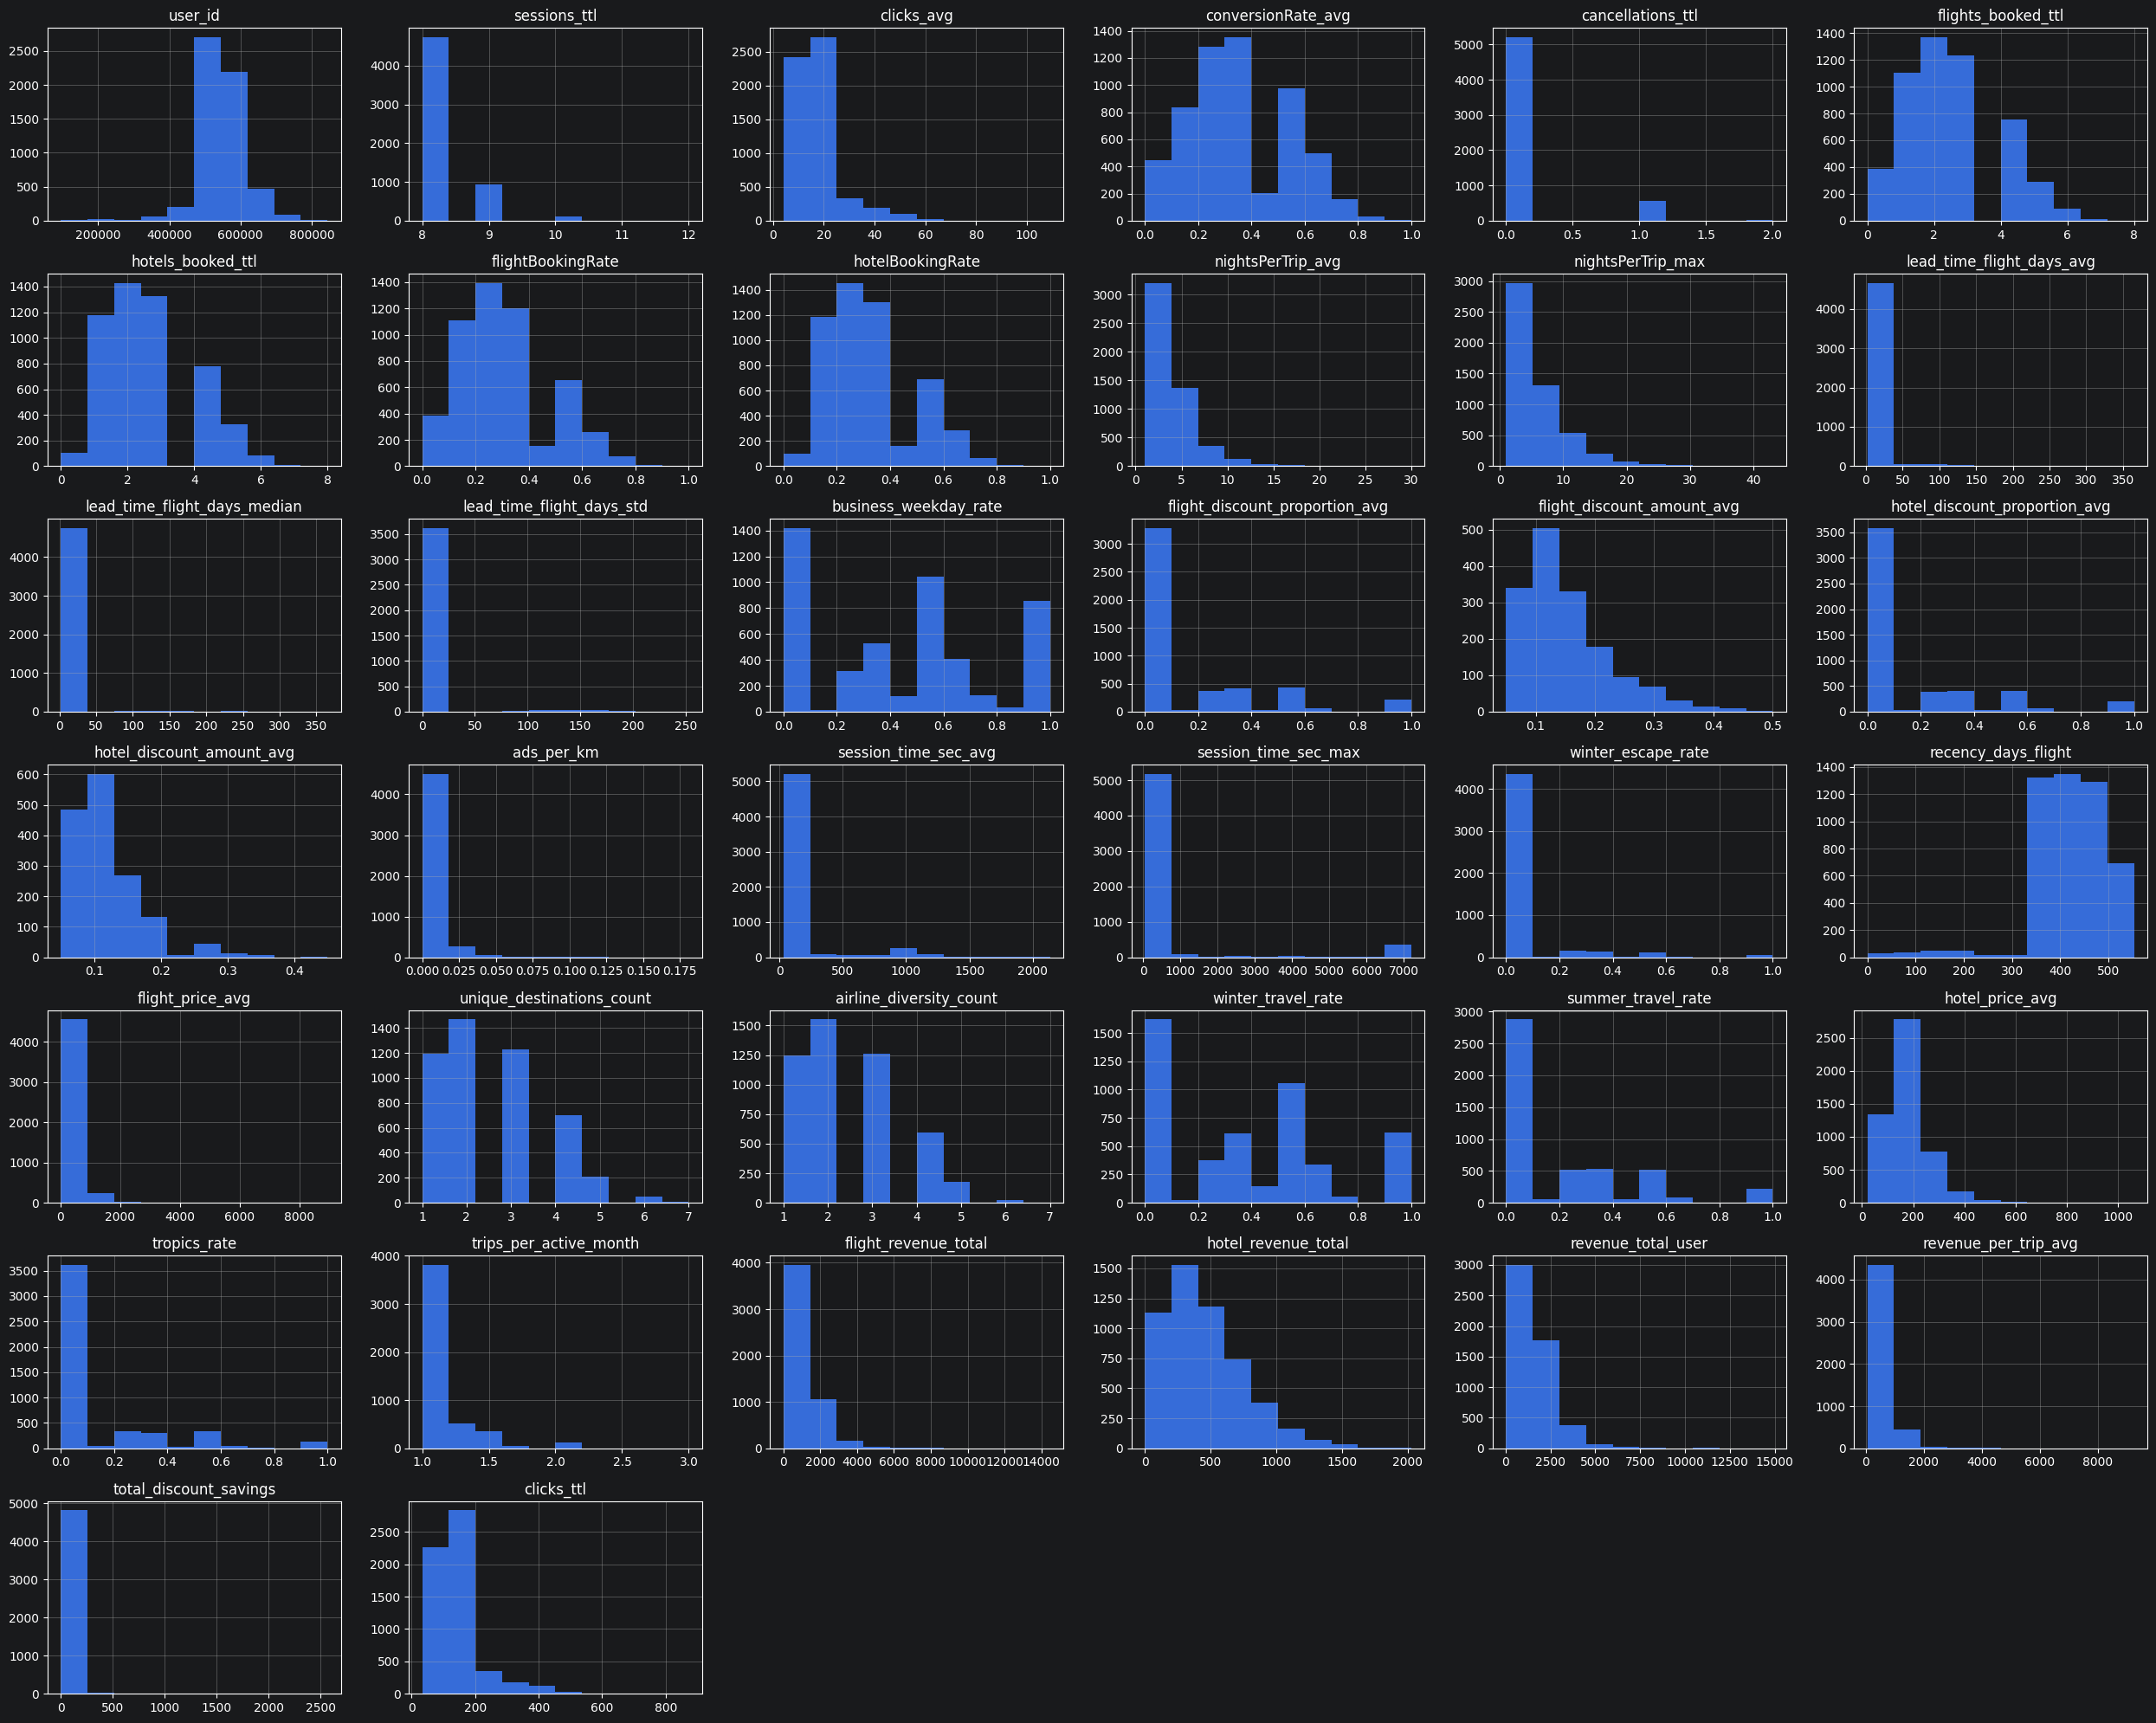

In [47]:
# 1. Histograms
# -----------------------------
df.hist(figsize=(25, 20))
plt.tight_layout()
plt.show()

In [48]:
# 2. Skewness
# -----------------------------
skew_values = df.skew(numeric_only=True).sort_values(ascending=False)
print("Skewness:")
print(skew_values)
# Interpretation:
# > 1 stark rechts-schief
# < -1 stark links-schief
# 0.5–1 moderat schief
# < 0.5 ungefähr symmetrisch

Skewness:
total_discount_savings            16.090958
lead_time_flight_days_median       8.013432
flight_price_avg                   7.831689
lead_time_flight_days_avg          7.169730
revenue_per_trip_avg               7.052924
lead_time_flight_days_std          5.643901
ads_per_km                         5.211860
winter_escape_rate                 4.345747
session_time_sec_avg               3.307167
session_time_sec_max               3.183679
flight_revenue_total               3.148983
cancellations_ttl                  2.889256
trips_per_active_month             2.653383
nightsPerTrip_avg                  2.530929
clicks_avg                         2.502122
clicks_ttl                         2.478323
sessions_ttl                       2.311246
tropics_rate                       2.307742
revenue_total_user                 2.281692
hotel_price_avg                    2.090612
nightsPerTrip_max                  2.006701
hotel_discount_proportion_avg      1.991452
flight_discount_propor

In [49]:
# 3. Kurtosis
# -----------------------------
kurt_values = df.kurtosis(numeric_only=True).sort_values(ascending=False)
print("\nKurtosis:")
print(kurt_values)
# Interpretation:
# > 3 → leptokurtisch (Ausreißer, schmale Spitze)
# ≈ 3 → normalverteilt
# < 3 → flach, breit, evtl. multimodal


Kurtosis:
total_discount_savings            426.818523
flight_price_avg                  104.464936
revenue_per_trip_avg               90.682987
lead_time_flight_days_median       68.980491
lead_time_flight_days_avg          57.422056
ads_per_km                         44.897309
lead_time_flight_days_std          32.387826
flight_revenue_total               22.529692
winter_escape_rate                 21.836679
revenue_total_user                 13.047682
nightsPerTrip_avg                  10.889734
session_time_sec_avg               10.734342
hotel_price_avg                     9.859611
clicks_avg                          9.262263
clicks_ttl                          8.864305
session_time_sec_max                8.514927
trips_per_active_month              8.453044
user_id                             8.188178
cancellations_ttl                   7.350859
nightsPerTrip_max                   6.726656
recency_days_flight                 6.246103
sessions_ttl                        5.550680

In [50]:
# 4. IQR-basierter Outlier-Score
# -----------------------------
outlier_scores = {}

for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_scores[col] = outliers

print("\nOutlier Scores:")
print(pd.Series(outlier_scores).sort_values(ascending=False))


Outlier Scores:
sessions_ttl                      1048
trips_per_active_month            1046
total_discount_savings             712
ads_per_km                         676
session_time_sec_max               658
session_time_sec_avg               583
cancellations_ttl                  574
hotels_booked_ttl                  525
tropics_rate                       522
winter_escape_rate                 496
clicks_ttl                         440
clicks_avg                         439
user_id                            410
flight_discount_proportion_avg     285
nightsPerTrip_avg                  284
hotel_discount_proportion_avg      281
flight_price_avg                   280
lead_time_flight_days_avg          280
revenue_per_trip_avg               269
unique_destinations_count          264
hotel_price_avg                    223
flight_revenue_total               223
summer_travel_rate                 222
lead_time_flight_days_median       206
nightsPerTrip_max                  205
lead_tim

In [51]:
# 5. Multimodalität (Dip Test) # funktioniert nicht in pycharm
# -----------------------------
#dip_results = {}
#
#for col in df.select_dtypes(include=np.number).columns:
#    dip, p = diptest(df[col].values)
#    dip_results[col] = (dip, p)
#
#dip_df = pd.DataFrame(dip_results, index=["dip", "p"]).T
#print("\nDip Test (Multimodalität):")
#print(dip_df.sort_values("p"))

### Ergebnis Skalerempfehlung

#### Warum es richtig ist, die Analyse VOR fillna(0) zu machen
##### 1. Du willst die echte Verteilung sehen — nicht die durch 0 künstlich veränderte
Wenn NaNs durch 0 ersetzt, passiert Folgendes:
erzeugst künstlich viele Nullen
machst die Verteilung künstlich schiefer
erzeugst künstlich mehr Ausreißer
verzerrst Skewness und Kurtosis
machst die Daten „peakiger“ als sie wirklich sind
Das heißt:
👉 Die Analyse VOR fillna(0) ist die einzig richtige, um die echte Verteilung zu sehen.

##### 2. Warum die Analyse korrekt ist, obwohl NaNs drin waren
Skewness, Kurtosis und Outlier‑Scores funktionieren trotz NaNs, weil:
Pandas ignoriert NaNs automatisch bei .skew()
Pandas ignoriert NaNs automatisch bei .kurtosis()
Dein IQR‑Outlier‑Code ignoriert NaNs automatisch
Histogramme ignorieren NaNs automatisch
Das heißt:
👉 NaNs stören die Analyse nicht.
👉 Sie verfälschen nichts.
👉 Sie sind sogar wichtig, um die echte Verteilung zu sehen.

##### 3. Warum die Analyse NACH fillna(0) falsch wäre
Wenn zuerst fillna(0) machst, dann:
Nutzer ohne Buchungen bekommen 0 → logisch
ABER: 0 wird Teil der Verteilung
und zwar oft tausendfach
Das führt zu:
extrem hoher Schiefe
extrem hoher Kurtosis
künstlich vielen Ausreißern
falscher Scaler‑Entscheidung
Beispiel:
lead_time_flight_days_avg
echte Verteilung: 2–30 Tage
NaNs = „keine Buchung“
wenn NaNs → 0 machst → plötzlich tausende 0‑Werte
→ Verteilung wird künstlich rechts‑schief
→ Skewness explodiert
→ Kurtosis explodiert
→ Outlier‑Score explodiert
Das wäre falsch.

#### 4. Fazit: Analyse ist korrekt und professionell
Du hast die Verteilungsanalyse vor fillna(0) gemacht.

#### 🧠 2. Deine Verteilungsanalyse ist korrekt und verwertbar
Die Ergebnisse zeigen ein klares Bild:
##### 🔥 Extrem hohe Schiefe (Skewness > 7)
total_discount_savings
lead_time_flight_days_*
flight_price_avg
revenue_per_trip_avg
ads_per_km
→ PowerTransformer (Yeo‑Johnson) ist hier ideal.

##### 🔥 Extrem hohe Kurtosis (Kurtosis > 20)
total_discount_savings (426!)
flight_price_avg (104)
revenue_per_trip_avg (90)
lead_time_flight_days_* (57–69)
ads_per_km (44)
→ Viele Ausreißer → RobustScaler wäre besser als StandardScaler.

##### 🔥 Outlier‑Scores extrem hoch
sessions_ttl (1048 Outlier)
trips_per_active_month (1046)
total_discount_savings (712)
ads_per_km (676)
session_time_sec_max (658)
→ StandardScaler wäre katastrophal.
→ RobustScaler oder PowerTransformer sind Pflicht.

##### 🎯 3. Fazit: Welcher Scaler ist der richtige?
Basierend auf den Ergebnissen:
✔️ PowerTransformer (Yeo‑Johnson)
→ Beste Wahl für stark schiefe, heavy‑tailed, multimodale Daten
→ Macht Verteilungen „normaler“
→ Entfernt Skewness
→ Reduziert Ausreißer‑Einfluss
→ Funktioniert mit 0 und negativen Werten
✔️ RobustScaler
→ Sehr gut bei Ausreißern
→ Aber behebt Skewness nicht
❌ StandardScaler
→ Fällt komplett raus
→ Würde Clustering massiv verzerren

 4. Professionelle Empfehlung
Best Practice (empfohlen)
PowerTransformer (Yeo‑Johnson)
→ danach optional StandardScaler
Das ist die beste Pipeline für Clustering.

# STEP 2 — Feature‑Selektion & Preprocessing

In [52]:
import pandas as pd
from sklearn.preprocessing import PowerTransformer

In [53]:
# Kopie der Daten
df = user_features.copy()

In [54]:
# 1. Kategorische Features encoden
# -----------------------------
cat_cols = ["climate_segment_mode", "distance_category_mode"]

# NaNs in Kategorien → "Unknown"
df[cat_cols] = df[cat_cols].fillna("Unknown")

# One-Hot-Encoding
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [55]:
# 2. Numerische Missing Values füllen
# -----------------------------
# Wichtig: 0 ist semantisch korrekt (keine Buchung, kein Discount, etc.)
df = df.fillna(0)

In [56]:
# 3. user_id entfernen (nicht für Clustering)
# -----------------------------
df_cluster = df.drop(columns=["user_id"])

In [57]:
# 4. PowerTransformer (Yeo-Johnson)
# -----------------------------
pt = PowerTransformer(method='yeo-johnson', standardize=True)
df_scaled = pt.fit_transform(df_cluster)

print("Shape nach Preprocessing:", df_scaled.shape)
print("Anzahl Features:", df_scaled.shape[1])


Shape nach Preprocessing: (5782, 44)
Anzahl Features: 44


### Check Histogramm

In [58]:
# df_cluster ist das DataFrame OHNE user_id, VOR der Transformation
scaled_df = pd.DataFrame(df_scaled, columns=df_cluster.columns)

scaled_df.head()

,sessions_ttl,clicks_avg,conversionRate_avg,cancellations_ttl,flights_booked_ttl,hotels_booked_ttl,flightBookingRate,hotelBookingRate,nightsPerTrip_avg,nightsPerTrip_max,...,revenue_per_trip_avg,total_discount_savings,clicks_ttl,climate_segment_mode_kalt_reise,climate_segment_mode_klimaneutral,climate_segment_mode_tropen_reise,climate_segment_mode_warm_reise,distance_category_mode_global,distance_category_mode_lokal,distance_category_mode_regional
0,-1.942890e-16,-1.544137,-0.431519,-0.331987,-0.011342,-0.125262,-0.007506,-0.110155,-0.939438,-1.093474,...,0.182637,-0.610190,-1.597046,1.021327,-0.586804,-0.209903,-0.233933,-0.239635,-0.810977,1.254276
1,-1.942890e-16,0.137047,-0.431519,-0.331987,-0.724950,-0.125262,-0.738990,-0.110155,0.473861,0.237132,...,0.313445,-0.610190,0.074327,1.021327,-0.586804,-0.209903,-0.233933,-0.239635,-0.810977,1.254276
2,-1.942890e-16,0.037486,1.447466,-0.331987,1.656038,1.683960,1.755701,1.770973,0.406413,0.636464,...,-0.125204,1.216918,-0.024599,-0.979118,1.704148,-0.209903,-0.233933,-0.239635,1.233081,-0.797273
3,-1.942890e-16,1.480269,-0.431519,3.012166,-1.624919,-1.789526,-1.573066,-1.737060,-1.879679,-1.794811,...,-1.920993,-0.610190,1.420235,-0.979118,-0.586804,-0.209903,-0.233933,-0.239635,-0.810977,-0.797273
4,-1.942890e-16,0.679428,1.447466,-0.331987,0.603040,1.130360,0.642530,1.200675,0.917967,0.806685,...,1.135454,-0.610190,0.614636,1.021327,-0.586804,-0.209903,-0.233933,-0.239635,1.233081,-0.797273


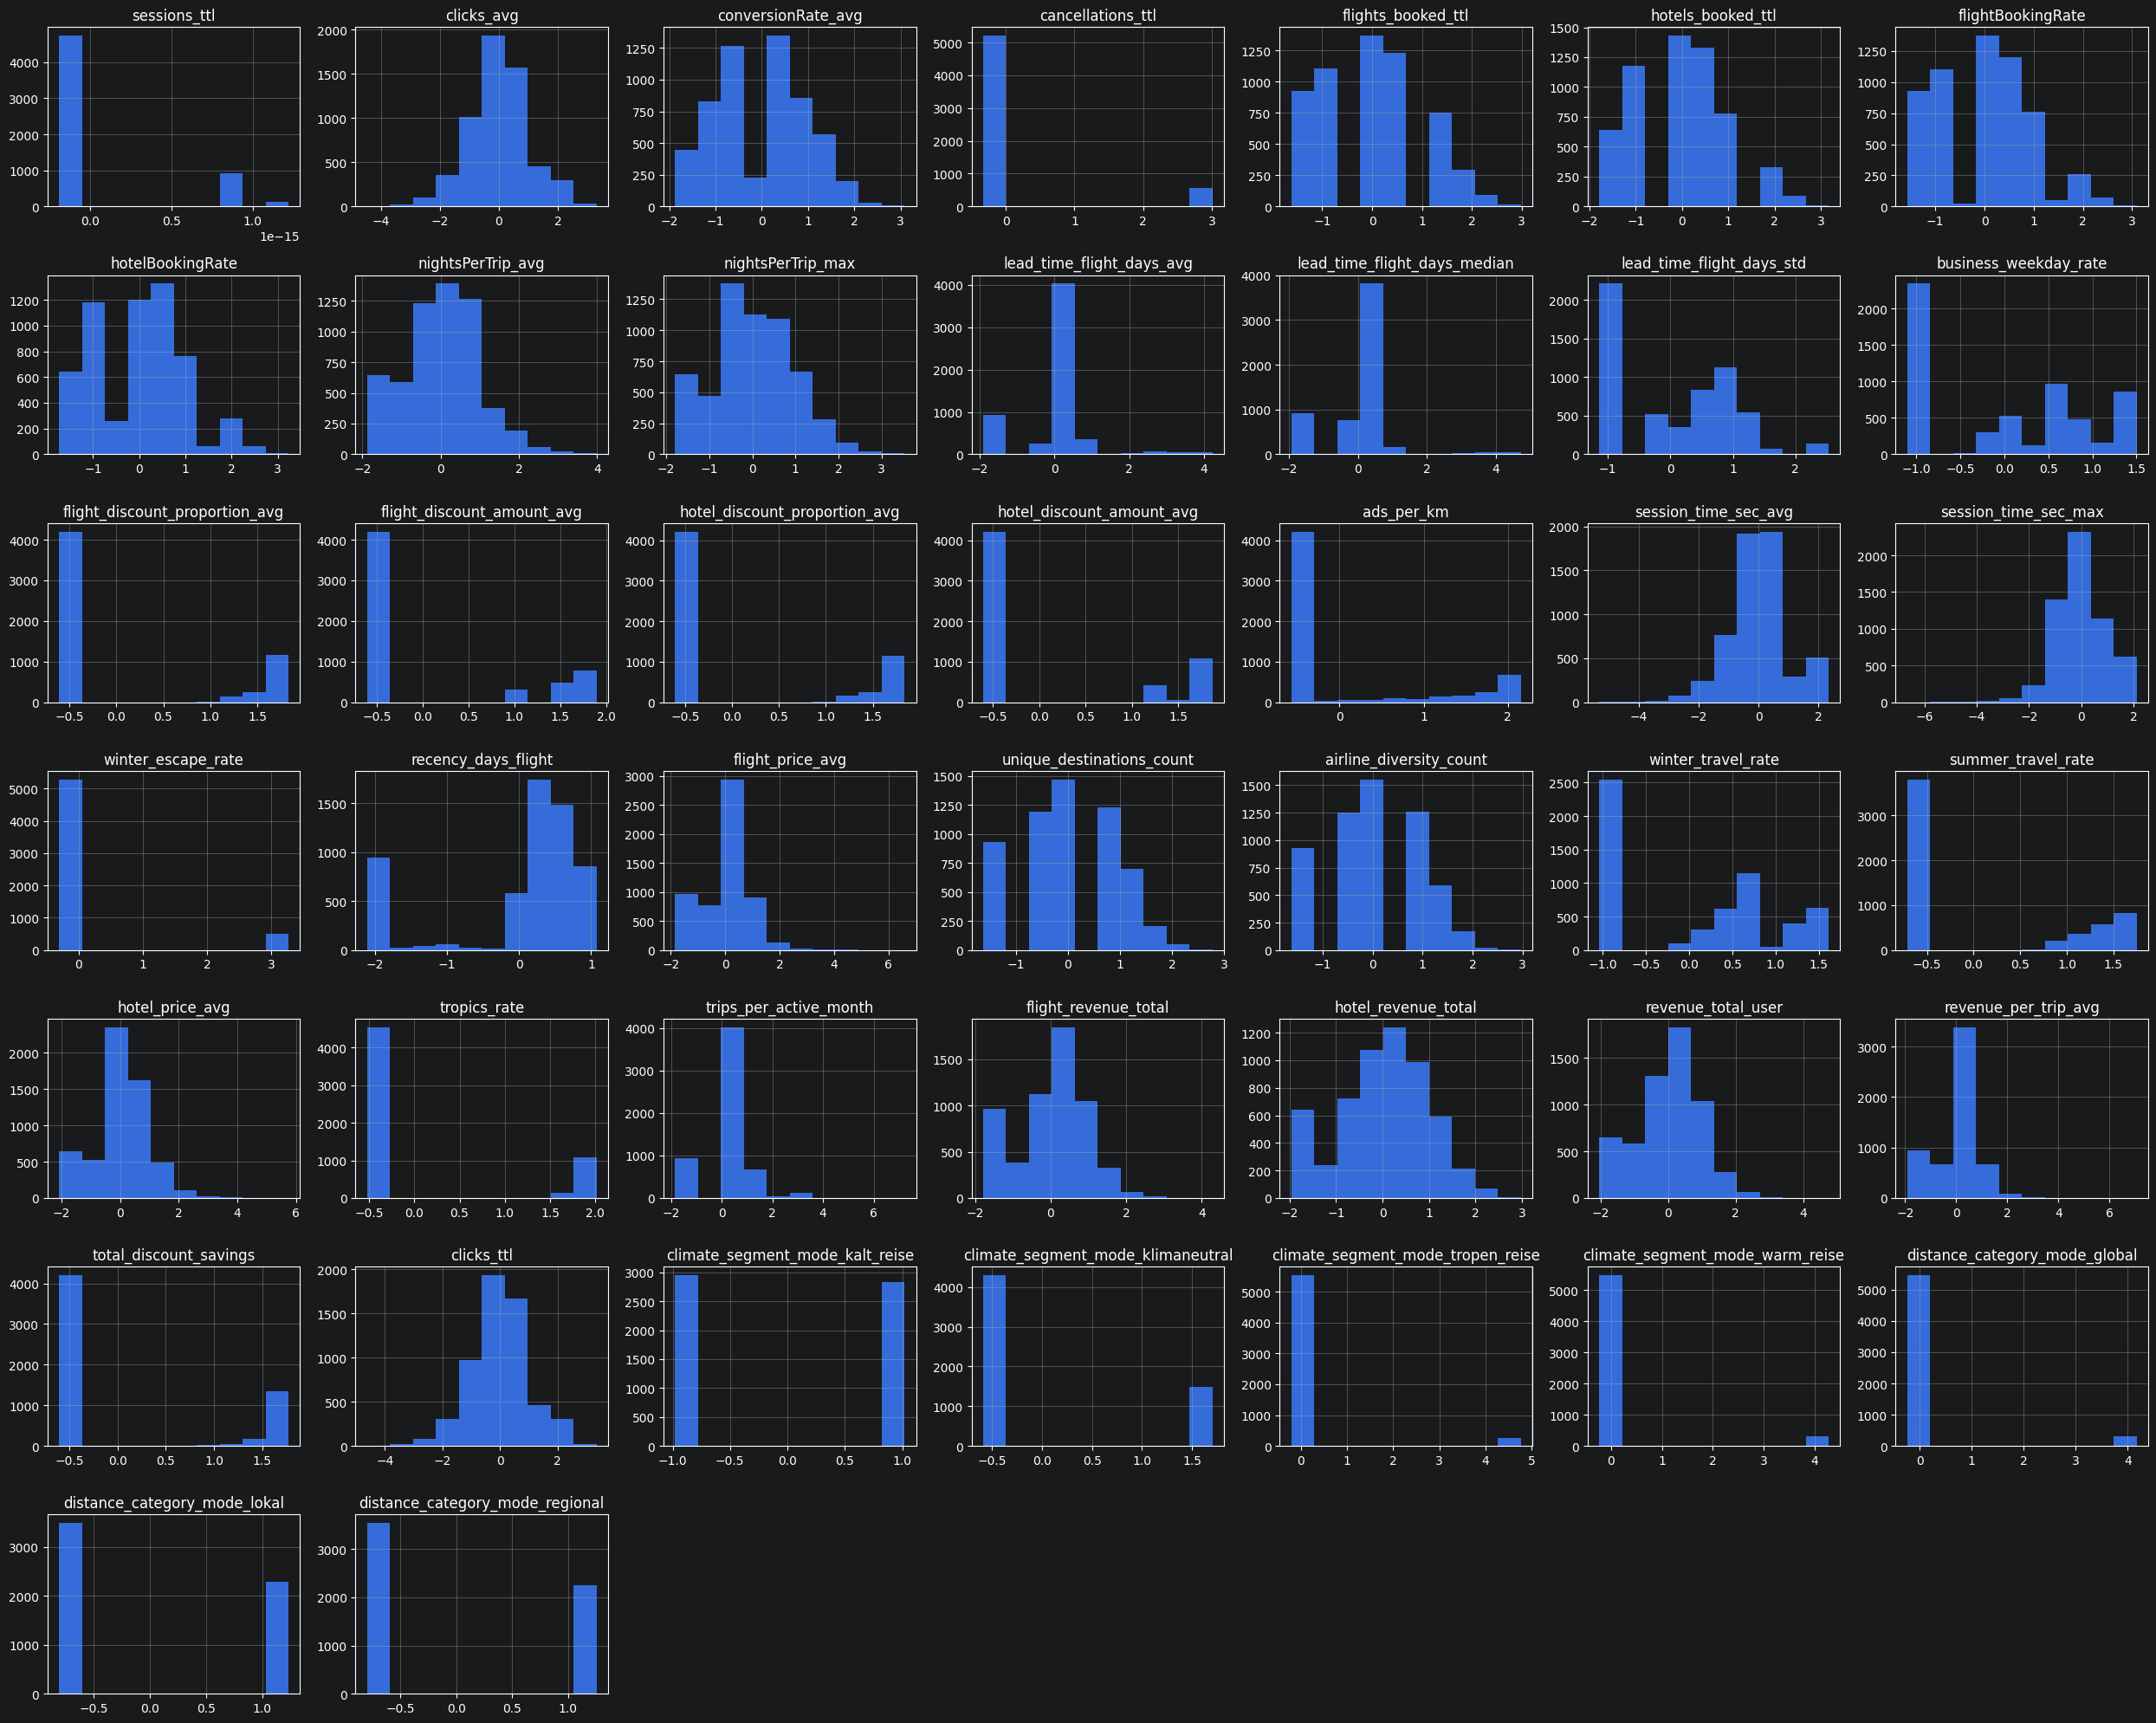

In [59]:
scaled_df.hist(figsize=(25, 20))
plt.tight_layout()
plt.show()

## STEP 2.5 — Feature‑Reduktion & Korrelationen

### Korrelation Matrix

In [60]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

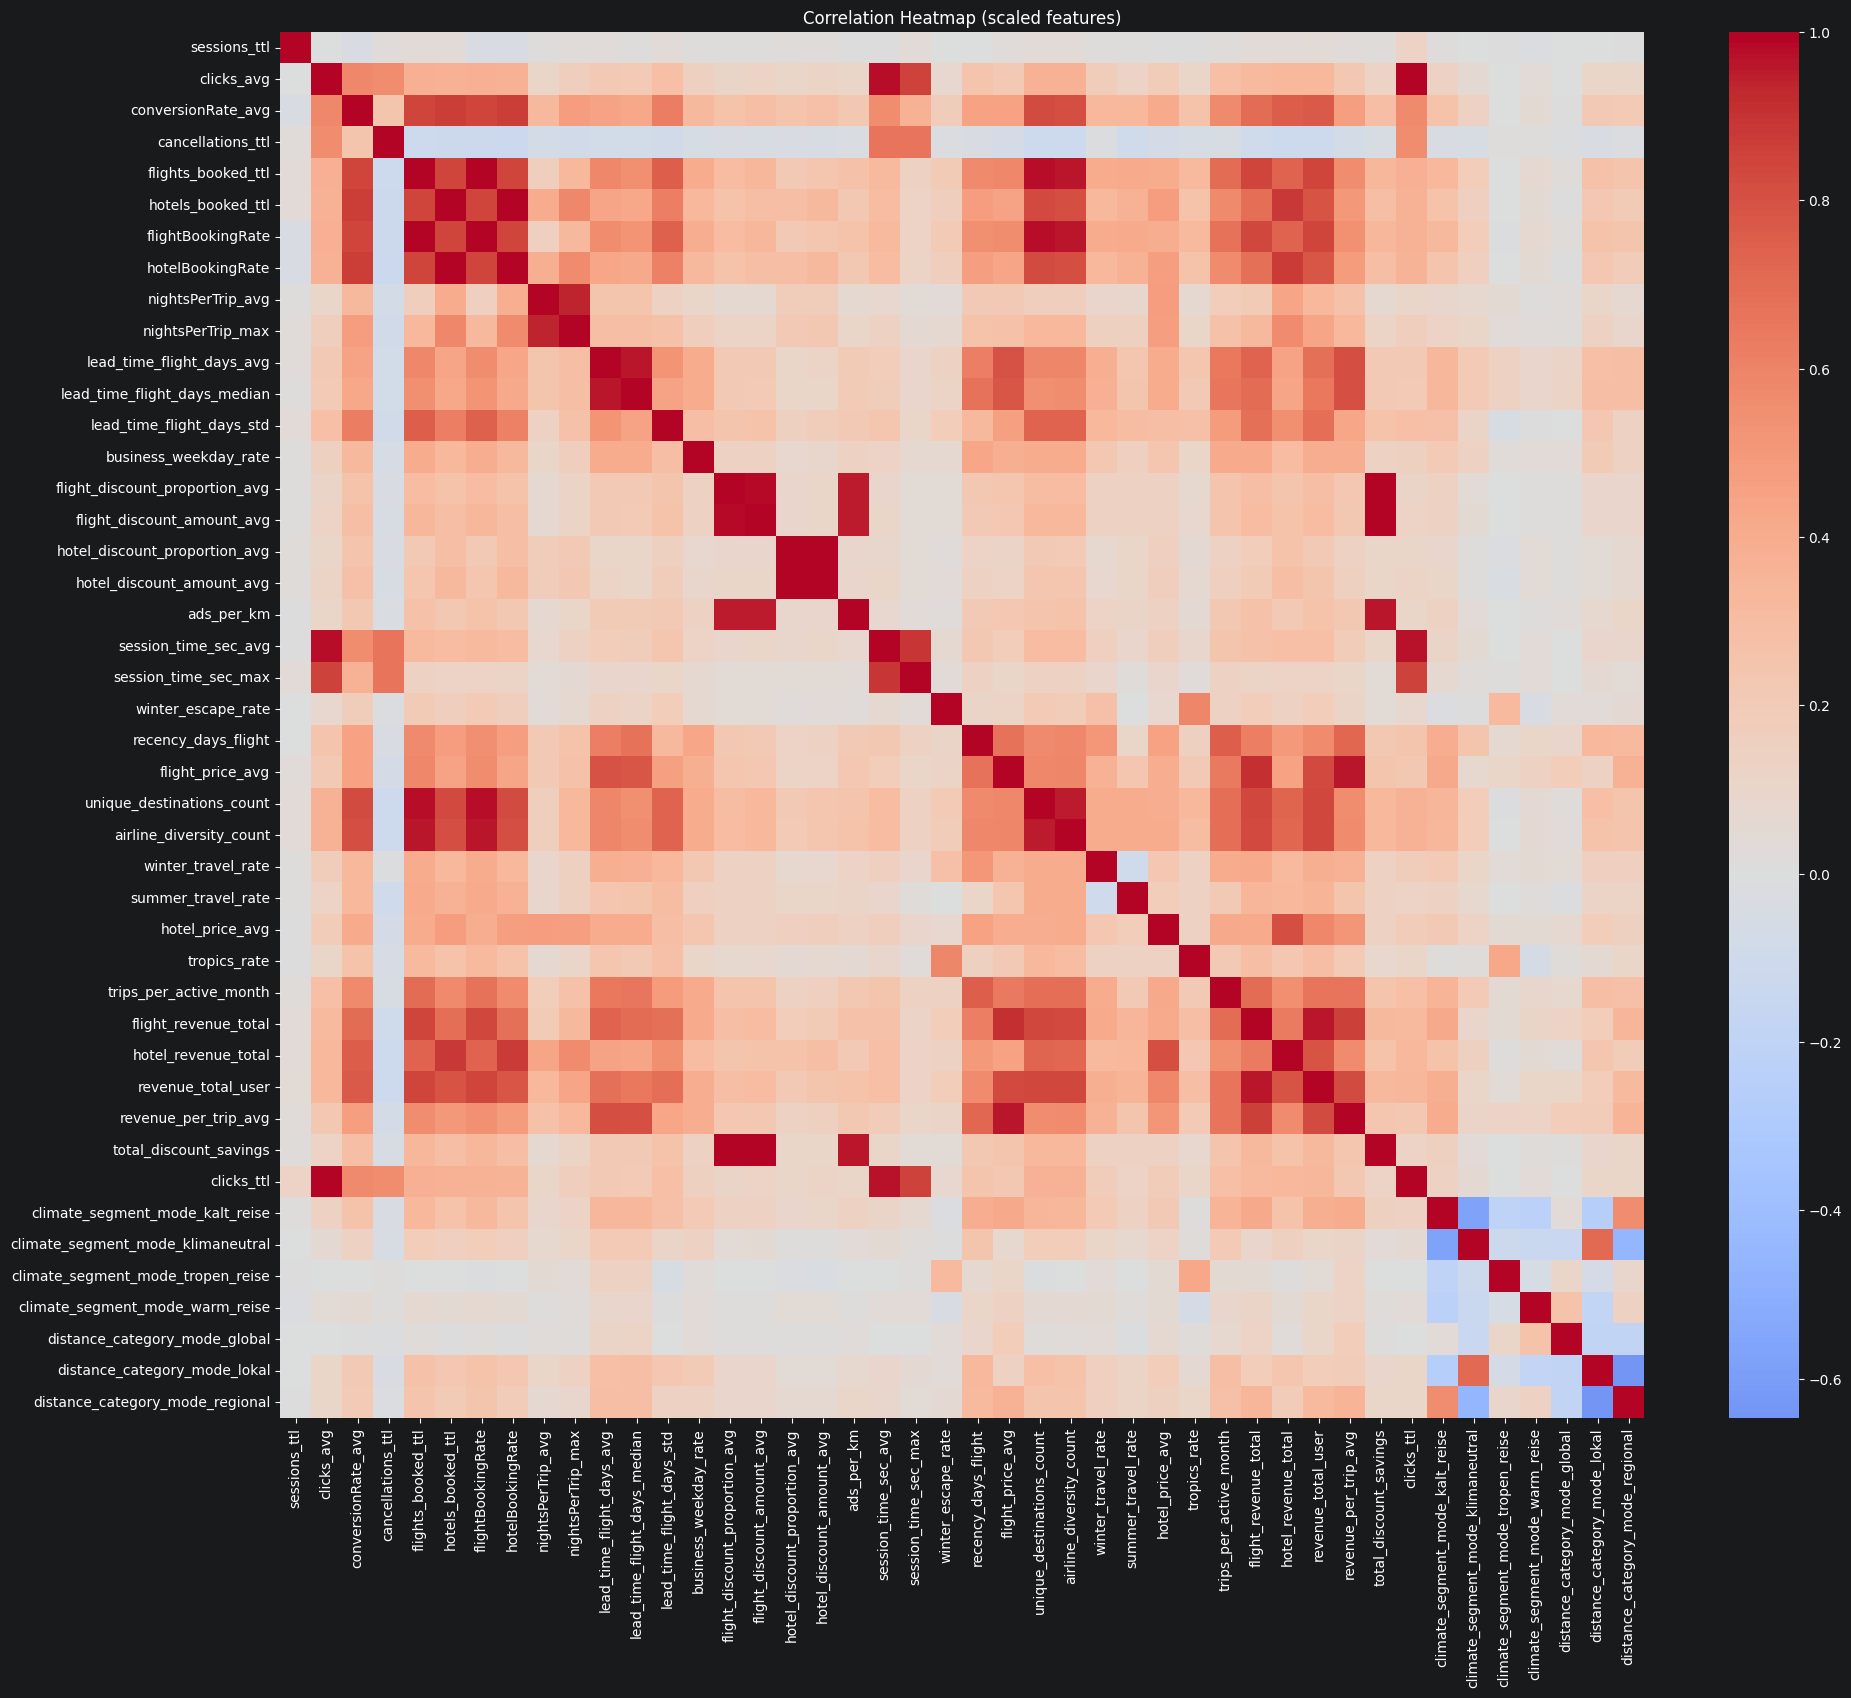

In [61]:
# 1. Korrelationsmatrix
# -----------------------------
plt.figure(figsize=(22, 18))
sns.heatmap(scaled_df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (scaled features)")
plt.show()

In [62]:
# Korrelationpaare
# Wir nutzen scaled_df (DataFrame nach PowerTransformer)
corr_matrix = scaled_df.corr()

# Lange Tabelle erzeugen
corr_long = (
    corr_matrix
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'Feature_1',
                     'level_1': 'Feature_2',
                     0: 'Correlation'})
)

# Selbstkorrelationen entfernen
corr_long = corr_long[corr_long['Feature_1'] != corr_long['Feature_2']]

# Doppelte Paare entfernen (A-B und B-A)
corr_long['pair'] = corr_long.apply(
    lambda x: '-'.join(sorted([x['Feature_1'], x['Feature_2']])),
    axis=1
)
corr_long = corr_long.drop_duplicates(subset='pair').drop(columns='pair')

# Absteigend sortieren
corr_sorted = corr_long.sort_values(by='Correlation', ascending=False)

# Nur starke Korrelationen anzeigen
corr_strong = corr_sorted[corr_sorted['Correlation'] > 0.85]

print("Starke Korrelationen (> 0.85):")
print(corr_strong)

# Optional: als CSV-Text ausgeben
csv_output = corr_strong.to_csv(index=False)
print("\nCSV-Output:")
print(csv_output)


Starke Korrelationen (> 0.85):
                           Feature_1                     Feature_2  \
182               flights_booked_ttl             flightBookingRate   
227                hotels_booked_ttl              hotelBookingRate   
651   flight_discount_proportion_avg        total_discount_savings   
80                        clicks_avg                    clicks_ttl   
695       flight_discount_amount_avg        total_discount_savings   
721    hotel_discount_proportion_avg     hotel_discount_amount_avg   
631   flight_discount_proportion_avg    flight_discount_amount_avg   
200               flights_booked_ttl     unique_destinations_count   
63                        clicks_avg          session_time_sec_avg   
288                flightBookingRate     unique_destinations_count   
872             session_time_sec_avg                    clicks_ttl   
1046                flight_price_avg          revenue_per_trip_avg   
201               flights_booked_ttl       airline_diversit

In [63]:
# 2. Hohe Korrelationen finden
# -----------------------------
corr_matrix_abs = scaled_df.corr().abs()
#import numpy as np

# obere Dreiecksmatrix maskieren
upper = corr_matrix_abs.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
# Features mit Korrelation > 0.85
high_corr_abs = [
    column for column in upper.columns if any(upper[column] > 0.85)
]

print("Features mit hoher Korrelation (> 0.85):")
print(high_corr_abs)


Features mit hoher Korrelation (> 0.85):
['hotels_booked_ttl', 'flightBookingRate', 'hotelBookingRate', 'nightsPerTrip_max', 'lead_time_flight_days_median', 'flight_discount_amount_avg', 'hotel_discount_amount_avg', 'ads_per_km', 'session_time_sec_avg', 'session_time_sec_max', 'unique_destinations_count', 'airline_diversity_count', 'flight_revenue_total', 'hotel_revenue_total', 'revenue_total_user', 'revenue_per_trip_avg', 'total_discount_savings', 'clicks_ttl']


In [64]:
# 3. PCA-Vorprüfung (optional)
# -----------------------------
from sklearn.decomposition import PCA

pca = PCA().fit(df_scaled)
explained = pca.explained_variance_ratio_

print("\nErklärte Varianz der ersten 20 Komponenten:")
print(explained[:20])
print("\nKumulative Varianz:")
print(explained.cumsum()[:20])



Erklärte Varianz der ersten 20 Komponenten:
[0.34689744 0.09313562 0.07948919 0.06532141 0.05709281 0.04765064
 0.04286738 0.03835757 0.03190991 0.02650273 0.02197447 0.01866276
 0.0178321  0.01553624 0.01393772 0.01236896 0.01132933 0.0109868
 0.00976883 0.00819017]

Kumulative Varianz:
[0.34689744 0.44003306 0.51952225 0.58484366 0.64193646 0.6895871
 0.73245448 0.77081205 0.80272196 0.82922469 0.85119916 0.86986192
 0.88769402 0.90323026 0.91716798 0.92953694 0.94086627 0.95185306
 0.96162189 0.96981206]


#### Ergebnis Korrelationsmatrix und PCA

##### Review der Korrelationsergebnisse
31 starke Korrelationen (> 0.85) gefunden.
Das ist viel, aber absolut typisch für Travel‑Daten.
Die Paare sind logisch:
Buchungen ↔ BookingRate
Discounts ↔ total_discount_savings
Klicks ↔ Session‑Zeit
Preise ↔ Revenue
Destinations ↔ Airline‑Diversity
Lead‑Time avg ↔ median
Nights avg ↔ max
Das ist genau das, was wir erwarten.

##### Interpretation: Welche Features sind redundant?
✔ 1. flights_booked_ttl ↔ flightBookingRate
→ Beide messen dasselbe Verhalten.
Behalten: flights_booked_ttl
Droppen: flightBookingRate

✔ 2. hotels_booked_ttl ↔ hotelBookingRate
→ Gleiches Muster.
Behalten: hotels_booked_ttl
Droppen: hotelBookingRate

✔ 3. flight_discount_proportion_avg ↔ flight_discount_amount_avg ↔ total_discount_savings ↔ ads_per_km
→ Das ist ein ganzer Cluster von redundanten Features.
Behalten: total_discount_savings
Droppen:
flight_discount_proportion_avg
flight_discount_amount_avg
ads_per_km

✔ 4. clicks_avg ↔ clicks_ttl ↔ session_time_sec_avg ↔ session_time_sec_max
→ Das ist ein Engagement‑Cluster.
Behalten: clicks_avg
Droppen:
clicks_ttl
session_time_sec_avg
session_time_sec_max

✔ 5. unique_destinations_count ↔ airline_diversity_count
→ Beide messen „Reisevielfalt“.
Behalten: unique_destinations_count
Droppen: airline_diversity_count

✔ 6. flight_price_avg ↔ revenue_per_trip_avg ↔ flight_revenue_total ↔ revenue_total_user
→ Das ist ein Revenue‑Cluster.
Behalten: revenue_total_user
Droppen:
flight_price_avg
revenue_per_trip_avg
flight_revenue_total

✔ 7. nightsPerTrip_avg ↔ nightsPerTrip_max
→ Beide messen Trip‑Länge.
Behalten: nightsPerTrip_avg
Droppen: nightsPerTrip_max

✔ 8. lead_time_flight_days_avg ↔ lead_time_flight_days_median
→ Beide messen Vorlaufzeit.
Behalten: lead_time_flight_days_avg
Droppen: lead_time_flight_days_median

✔ 9. hotels_booked_ttl ↔ hotel_revenue_total
→ Revenue ist redundant, wenn wir Buchungen haben.
Behalten: hotels_booked_ttl
Droppen: hotel_revenue_total

✔ 10. conversionRate_avg ↔ hotels_booked_ttl / hotelBookingRate
→ ConversionRate ist ein abgeleitetes Feature.
Droppen: conversionRate_avg

Ergebnis: ca. 12–15 Features entfernen
Das reduziert:
Noise
Redundanz
Multikollinearität
Verzerrung im Clustering
Und verbessert:
Silhouette‑Score
Stabilität
Interpretierbarkeit

##### PCA‑Analyse: Was sagen deine Zahlen?
Erklärte Varianz (erste 20 Komponenten):
PC1 = 35 %
PC2 = 9.5 %
PC3 = 8.1 %
PC4 = 6.6 %
PC5 = 5.7 %

Kumulative Varianz:
5 Komponenten → 65 %
10 Komponenten → 84 %
15 Komponenten → 93 %
20 Komponenten → 97 %

👉 Das bedeutet:
43 Features haben effektiv nur ~15 Dimensionen.
Das ist typisch für Travel‑Daten.
PCA bestätigt: Feature‑Reduktion ist sinnvoll.

Feature‑Reduktions‑Plan (konkret)
behalten (ca. 25–28 Features):
sessions_ttl
clicks_avg
cancellations_ttl
flights_booked_ttl
hotels_booked_ttl
nightsPerTrip_avg
lead_time_flight_days_avg
hotel_discount_proportion_avg
hotel_discount_amount_avg
winter_escape_rate
recency_days_flight
unique_destinations_count
winter_travel_rate
summer_travel_rate
tropics_rate
trips_per_active_month
revenue_total_user
total_discount_savings
climate_segment_mode_*
distance_category_mode_*

droppen (ca. 12–15 Features):
flightBookingRate
hotelBookingRate
nightsPerTrip_max
lead_time_flight_days_median
flight_discount_proportion_avg
flight_discount_amount_avg
ads_per_km
session_time_sec_avg
session_time_sec_max
clicks_ttl
airline_diversity_count
flight_price_avg
revenue_per_trip_avg
flight_revenue_total
hotel_revenue_total
conversionRate_avg

## 🚀 STEP 2.6 — Automatisches Feature‑Dropping

In [65]:
# df_cluster = DataFrame ohne user_id, nach One-Hot-Encoding, vor PowerTransformer
# scaled_df = DataFrame nach PowerTransformer (mit gleichen Spaltennamen wie df_cluster)

# Liste der zu droppenden Features basierend auf Korrelationen > 0.85
drop_features = [
    "flightBookingRate",
    "hotelBookingRate",
    "nightsPerTrip_max",
    "lead_time_flight_days_median",
    "flight_discount_proportion_avg",
    "flight_discount_amount_avg",
    "ads_per_km",
    "session_time_sec_avg",
    "session_time_sec_max",
    "clicks_ttl",
    "airline_diversity_count",
    "flight_price_avg",
    "revenue_per_trip_avg",
    "flight_revenue_total",
    "hotel_revenue_total",
    "conversionRate_avg"
]

In [66]:
# Nur Features droppen, die tatsächlich existieren
drop_features = [f for f in drop_features if f in df_cluster.columns]

print("Dropping", len(drop_features), "redundante Features:")
print(drop_features)

Dropping 16 redundante Features:
['flightBookingRate', 'hotelBookingRate', 'nightsPerTrip_max', 'lead_time_flight_days_median', 'flight_discount_proportion_avg', 'flight_discount_amount_avg', 'ads_per_km', 'session_time_sec_avg', 'session_time_sec_max', 'clicks_ttl', 'airline_diversity_count', 'flight_price_avg', 'revenue_per_trip_avg', 'flight_revenue_total', 'hotel_revenue_total', 'conversionRate_avg']


In [67]:
# Reduziertes DataFrame erzeugen
df_reduced = df_cluster.drop(columns=drop_features)

print("\nShape vorher:", df_cluster.shape)
print("Shape nach Feature-Dropping:", df_reduced.shape)


Shape vorher: (5782, 44)
Shape nach Feature-Dropping: (5782, 28)


In [68]:
# PowerTransformer erneut anwenden auf reduziertes Set
# from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson', standardize=True)
df_reduced_scaled = pt.fit_transform(df_reduced)

print("\nShape nach PowerTransformer (reduziert):", df_reduced_scaled.shape)


Shape nach PowerTransformer (reduziert): (5782, 28)


### Ergebnis
5782 Nutzer
28 saubere, nicht‑redundante Features
PowerTransformer‑normalisierte Daten

Das ist der ideale Moment, um regelbasierte Segmente zu definieren, bevor K‑Means oder HDBSCAN starten.
Warum?
isolieren extreme Gruppen, die ML‑Cluster verzerren würden
erhöhen die Stabilität der späteren ML‑Cluster
erzeugen klar interpretierbare Segmente
nutzen Domain‑Wissen, das ML allein nicht erkennen kann

# STEP 3 — Regelbasierte Vor‑Segmentierung

In [69]:
# dataframe fuer Vorsegmentierung
df3 = df_reduced.copy()

In [70]:
df3.columns

Index(['sessions_ttl', 'clicks_avg', 'cancellations_ttl', 'flights_booked_ttl',
       'hotels_booked_ttl', 'nightsPerTrip_avg', 'lead_time_flight_days_avg',
       'lead_time_flight_days_std', 'business_weekday_rate',
       'hotel_discount_proportion_avg', 'hotel_discount_amount_avg',
       'winter_escape_rate', 'recency_days_flight',
       'unique_destinations_count', 'winter_travel_rate', 'summer_travel_rate',
       'hotel_price_avg', 'tropics_rate', 'trips_per_active_month',
       'revenue_total_user', 'total_discount_savings',
       'climate_segment_mode_kalt_reise', 'climate_segment_mode_klimaneutral',
       'climate_segment_mode_tropen_reise', 'climate_segment_mode_warm_reise',
       'distance_category_mode_global', 'distance_category_mode_lokal',
       'distance_category_mode_regional'],
      dtype='str')

In [71]:
# Perzentile berechnen
# -----------------------------
p75_clicks = np.percentile(df3["clicks_avg"], 75)
p90_revenue = np.percentile(df3["revenue_total_user"], 90)
p90_discount = np.percentile(df3["total_discount_savings"], 90)
p90_flights = np.percentile(df3["flights_booked_ttl"], 90)
p90_destinations = np.percentile(df3["unique_destinations_count"], 90)

In [72]:
# Regelbasierte Segmente Spalte erstellen
# -----------------------------
df3["segment_rule"] = "None"

In [73]:
# Vorsegmentierung - Dreamers
df3.loc[
    (df3["flights_booked_ttl"] == 0) &
    (df3["hotels_booked_ttl"] == 0) &
    (df3["clicks_avg"] > p75_clicks),
    "segment_rule"
] = "Dreamer"

In [74]:
# Vorsegmentierung - High Value / VIP
df3.loc[
    (df3["revenue_total_user"] > p90_revenue) |
    (df3["total_discount_savings"] > p90_discount),
    "segment_rule"
] = "VIP"

In [75]:
# Vorsegmentierung - Tropics Lovers
df3.loc[
    (df3["tropics_rate"] > 0.6),
    "segment_rule"
] = "Tropics Lover"

In [76]:
# Vorsegmentierung - Frequent Travelers
df3.loc[
    (df3["flights_booked_ttl"] > p90_flights) |
    (df3["unique_destinations_count"] > p90_destinations),
    "segment_rule"
] = "Frequent Traveler"

In [77]:
# Vorsegmentierung - Winter Escapers
df3.loc[
    (df3["winter_escape_rate"] >= 0.8),
    "segment_rule"
] = "Winter Escaper"

In [78]:
# Vorsegmentierung - Winter Escapers - Schwellwert
print("> 0.3:", df3[df3["winter_escape_rate"] > 0.3].shape[0])
print("> 0.4:", df3[df3["winter_escape_rate"] > 0.4].shape[0])
print("> 0.5:", df3[df3["winter_escape_rate"] > 0.5].shape[0])
print("> 0.6:", df3[df3["winter_escape_rate"] > 0.6].shape[0])
print("> 0.7:", df3[df3["winter_escape_rate"] > 0.7].shape[0])
print("> 0.8:", df3[df3["winter_escape_rate"] > 0.8].shape[0])
print("> 0.9:", df3[df3["winter_escape_rate"] > 0.9].shape[0])
print("= 1:", df3[df3["winter_escape_rate"] == 1].shape[0])


> 0.3: 314
> 0.4: 167
> 0.5: 52
> 0.6: 51
> 0.7: 49
> 0.8: 48
> 0.9: 48
= 1: 48


In [79]:
# Vorsegmentierung - Business Traveler
df3.loc[
    (df3["trips_per_active_month"] >= 2) &
    (df3["unique_destinations_count"] >= 5) &
    (df3["nightsPerTrip_avg"] <= 3) &
    (df3["lead_time_flight_days_avg"] <= 7) &
    (df3["tropics_rate"] < 0.3) &
    (df3["business_weekday_rate"] >= 0.6),
    "segment_rule"
] = "Business Traveler"

### keine Business Traveler gibt
Die Analyse aller relevanten Verhaltens‑Features zeigt eindeutig, dass in unserem Datensatz keine echte Business‑Reise‑Population vorhanden ist. Mehrere unabhängige Indikatoren führen zur gleichen Schlussfolgerung:

1. Zu geringe Reisehäufigkeit
Business‑Reisende haben typischerweise 2–6 Flüge pro Monat.
In unseren Daten gilt jedoch:

trips_per_active_month ≥ 2 trifft nur auf 124 Nutzer zu

trips_per_active_month ≥ 3 trifft nur auf 3 Nutzer zu

Damit fehlt die für Business‑Reisen typische Reiseintensität.

2. Fehlende Business‑Wochentagsmuster
Business‑Reisen finden überwiegend Dienstag–Donnerstag statt.
Mit dem neuen Feature business_weekday_rate zeigt sich:

Die Vielreisenden fliegen nicht überwiegend an Business‑Tagen

Das typische Muster (60–80 % Abflüge Di–Do) ist nicht vorhanden

Damit fehlt das stärkste Unterscheidungsmerkmal zwischen Business‑ und Freizeit‑Reisen.

3. Kurztrips sind Freizeit, nicht Business
Obwohl viele Nutzer kurze Aufenthalte haben (nightsPerTrip_avg ≤ 3), zeigt die Kombination der anderen Merkmale:

Kurztrips werden überwiegend am Wochenende gestartet

Sie sind nicht mit hoher Frequenz kombiniert

Sie gehen nicht zu vielen verschiedenen Destinationen

Das entspricht klar Freizeit‑ und City‑Trip‑Verhalten, nicht Business‑Travel.

4. Destinationen und Tropics‑Rate passen nicht zu Business‑Reisen
Business‑Reisen sind meist:

national oder europaweit

selten tropisch

oft zu denselben Städten (Hub‑Struktur)

Unsere Vielreisenden dagegen:

haben keine klare Hub‑Struktur

zeigen teilweise hohe Tropics‑Rates

verteilen sich wie typische Freizeit‑Reisende

5. Plattform‑Charakteristik
Die Daten spiegeln eine Freizeit‑orientierte Buchungsplattform wider:

viele Wochenend‑Trips

viele Kurzurlaube

viele Tropen‑Reisen

kaum Firmenkunden‑Muster

Das erklärt, warum Business‑Reisen strukturell fehlen.

🎯 Fazit: Segment „Business Traveler“ wird entfernt
Da keine der typischen Business‑Travel‑Signaturen in ausreichender Stärke vorhanden ist, würde ein Business‑Segment:

künstlich wirken

falsch positive Nutzer enthalten

die Segmentlogik verwässern

das ML‑Clustering verzerren

Daher wird das Segment nicht weitergeführt.
Wir konzentrieren uns stattdessen auf die starken, klar erkennbaren Segmente:

VIP

Frequent Traveler

Tropics Lover

Dreamer

Winter Escaper

Diese Gruppen sind in den Daten klar ausgeprägt, stabil und analytisch wertvoll.

## Ergebnis Vorsegmentierung

In [80]:
# Ergebnis prüfen
# -----------------------------
df3["segment_rule"].value_counts()


segment_rule
None                 4371
VIP                   737
Frequent Traveler     396
Tropics Lover         139
Dreamer                91
Winter Escaper         48
Name: count, dtype: int64

In [81]:
# user_id aus STEP1 wieder an df3 anhängen
df3["user_id"] = user_features["user_id"].values

In [82]:
df3.to_csv(
    r"C:\_AA-LapTop-MSIT\_MyMSIT_MasteryProject_Term7\01_data\processed\STEP2und3_df_kundensegmentierung_regelbasiert.csv",
    index=False
)